# 06 — Evaluation & Comparison

This notebook provides a final evaluation and comparison of the three anomaly detection models trained on the NASA SMAP/MSL dataset:
- **LSTM Predictor**
- **Normalizing Flows (MAF)**
- **Diffusion (DDPM)**

Two evaluation protocols are reported:
- **Raw**: threshold predictions at the val-set 95th percentile score, compute metrics directly.
- **Point-Adjust (PA)**: standard in SMAP/MSL literature — if *any* timestep in a true anomaly segment is detected, the *entire* segment is marked detected. PA inflates F1 significantly; both are reported so results can be compared fairly.

In [140]:
import warnings
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

warnings.filterwarnings("ignore")

# ── Constants ──────────────────────────────────────────────────────────────────
WINDOW_SIZE = 100
MODELS = ["lstm", "flows", "diffusion", "baseline"]
RESULTS_DIR = Path("results")
LABELS_FILE = Path("labeled_anomalies.csv")
MODEL_NAMES = {
    "lstm": "LSTM Predictor",
    "flows": "Normalizing Flows (MAF)",
    "diffusion": "Diffusion (DDPM)",
    "baseline": "Isolation Forest",
}

print("Imports OK")
print(f"WINDOW_SIZE = {WINDOW_SIZE}")
print(f"MODELS      = {MODELS}")
print(f"RESULTS_DIR = {RESULTS_DIR}")
print(f"LABELS_FILE = {LABELS_FILE}")

Imports OK
WINDOW_SIZE = 100
MODELS      = ['lstm', 'flows', 'diffusion', 'baseline']
RESULTS_DIR = results
LABELS_FILE = labeled_anomalies.csv


In [141]:
# ── Load labels ────────────────────────────────────────────────────────────────
try:
    labels_df = pd.read_csv(LABELS_FILE)
    labels_df["anomaly_sequences"] = labels_df["anomaly_sequences"].apply(ast.literal_eval)
    print(f"Loaded labels: {len(labels_df)} entities")
    print(labels_df.head())
except FileNotFoundError:
    warnings.warn(f"{LABELS_FILE} not found. Cannot proceed without labels.")
    labels_df = pd.DataFrame(columns=["chan_id", "spacecraft", "anomaly_sequences", "class", "num_values"])

# ── Find entities with scores for ALL 3 models ─────────────────────────────────
def get_scored_entities(model):
    model_dir = RESULTS_DIR / model
    if not model_dir.exists():
        return set()
    return {p.stem.replace("_test_scores", "") for p in model_dir.glob("*_test_scores.npy")}

entity_sets = {m: get_scored_entities(m) for m in MODELS}
fully_evaluated = set.intersection(*entity_sets.values()) if entity_sets else set()

print(f"\nEntities with scores per model:")
for m, s in entity_sets.items():
    print(f"  {MODEL_NAMES[m]}: {len(s)} entities")
print(f"\nFully evaluated (all 3 models): {len(fully_evaluated)} entities")

# Filter labels to fully-evaluated entities
if len(labels_df) > 0:
    labels_df = labels_df[labels_df["chan_id"].isin(fully_evaluated)].reset_index(drop=True)
    print(f"Label rows retained: {len(labels_df)}")

Loaded labels: 82 entities
  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  

Entities with scores per model:
  LSTM Predictor: 82 entities
  Normalizing Flows (MAF): 82 entities
  Diffusion (DDPM): 82 entities
  Isolation Forest: 82 entities

Fully evaluated (all 3 models): 82 entities
Label rows retained: 82


## Evaluation Utilities

In [142]:
def build_ground_truth(anomaly_sequences, test_len, window_size):
    labels = np.zeros(test_len - window_size, dtype=int)
    for start, end in anomaly_sequences:
        score_start = max(0, start - window_size)
        score_end = min(test_len - window_size, end - window_size + 1)
        if score_end > score_start:
            labels[score_start:score_end] = 1
    return labels


def point_adjust(scores, labels):
    threshold = np.percentile(scores, 95)
    preds = (scores >= threshold).astype(int)
    in_anomaly = False
    segments = []
    for i, l in enumerate(labels):
        if l == 1 and not in_anomaly:
            seg_start = i
            in_anomaly = True
        elif l == 0 and in_anomaly:
            segments.append((seg_start, i))
            in_anomaly = False
    if in_anomaly:
        segments.append((seg_start, len(labels)))
    for seg_start, seg_end in segments:
        if preds[seg_start:seg_end].any():
            preds[seg_start:seg_end] = 1
    return preds


def evaluate_entity(scores, labels, val_scores):
    if labels.sum() == 0 or (1 - labels).sum() == 0:
        return None
    if len(val_scores) == 0:
        # No val data: fall back to test score distribution for threshold
        threshold = np.percentile(scores, 95)
    else:
        threshold = np.percentile(val_scores, 95)
    raw_preds = (scores >= threshold).astype(int)
    pa_preds = point_adjust(scores, labels)
    try:
        auc = roc_auc_score(labels, scores)
    except Exception:
        auc = float("nan")
    p_raw, r_raw, f1_raw, _ = precision_recall_fscore_support(
        labels, raw_preds, average="binary", zero_division=0
    )
    p_pa, r_pa, f1_pa, _ = precision_recall_fscore_support(
        labels, pa_preds, average="binary", zero_division=0
    )
    return {
        "auc_roc": auc,
        "f1_raw": f1_raw,
        "precision_raw": p_raw,
        "recall_raw": r_raw,
        "f1_pa": f1_pa,
        "precision_pa": p_pa,
        "recall_pa": r_pa,
    }


print("Evaluation utilities defined.")


Evaluation utilities defined.


## Per-Entity Results

In [143]:
rows = []

for _, label_row in labels_df.iterrows():
    entity_id = label_row["chan_id"]
    spacecraft = label_row["spacecraft"]
    anomaly_sequences = label_row["anomaly_sequences"]

    for model in MODELS:
        test_path = RESULTS_DIR / model / f"{entity_id}_test_scores.npy"
        val_path  = RESULTS_DIR / model / f"{entity_id}_val_scores.npy"

        try:
            test_scores = np.load(test_path)
            val_scores  = np.load(val_path)
        except FileNotFoundError as e:
            warnings.warn(f"Missing score file for {entity_id} / {model}: {e}")
            continue
        except Exception as e:
            warnings.warn(f"Error loading scores for {entity_id} / {model}: {e}")
            continue

        # test_len = len(test_scores) + WINDOW_SIZE  (stride-1 windows)
        test_len = len(test_scores) + WINDOW_SIZE
        ground_truth = build_ground_truth(anomaly_sequences, test_len, WINDOW_SIZE)

        # Sanity-check lengths align
        if len(ground_truth) != len(test_scores):
            warnings.warn(
                f"Length mismatch for {entity_id}/{model}: "
                f"ground_truth={len(ground_truth)}, test_scores={len(test_scores)}"
            )
            # Align by taking the minimum length
            min_len = min(len(ground_truth), len(test_scores))
            ground_truth = ground_truth[:min_len]
            test_scores  = test_scores[:min_len]

        metrics = evaluate_entity(test_scores, ground_truth, val_scores)
        if metrics is None:
            continue

        rows.append({
            "entity":        entity_id,
            "spacecraft":    spacecraft,
            "model":         model,
            **metrics,
        })

results_df = pd.DataFrame(rows)

# Save
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(RESULTS_DIR / "all_results.csv", index=False)
print(f"Saved {len(results_df)} rows to {RESULTS_DIR / 'all_results.csv'}")
print(f"\nSchema: {list(results_df.columns)}")
print(f"\nHead:")
results_df.head(9)

Saved 328 rows to results/all_results.csv

Schema: ['entity', 'spacecraft', 'model', 'auc_roc', 'f1_raw', 'precision_raw', 'recall_raw', 'f1_pa', 'precision_pa', 'recall_pa']

Head:


,entity,spacecraft,model,auc_roc,f1_raw,precision_raw,recall_raw,f1_pa,precision_pa,recall_pa
0,P-1,SMAP,lstm,0.489824,0.100815,0.081616,0.131824,0.797663,0.663428,1.000000
1,P-1,SMAP,flows,0.442340,0.032147,0.116667,0.018642,0.424159,0.437677,0.411451
2,P-1,SMAP,diffusion,0.400646,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,P-1,SMAP,baseline,0.458831,0.075169,0.069954,0.081225,0.794709,0.659350,1.000000
4,S-1,SMAP,lstm,0.671616,0.000000,0.000000,0.000000,0.716800,0.558603,1.000000
5,S-1,SMAP,flows,0.730569,0.000000,0.000000,0.000000,0.722581,0.565657,1.000000
6,S-1,SMAP,diffusion,0.409246,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,S-1,SMAP,baseline,0.267913,0.038760,0.029691,0.055804,0.717374,0.559301,1.000000
8,E-1,SMAP,lstm,0.627520,0.000000,0.000000,0.000000,0.706537,0.546237,1.000000


## Aggregate Results

In [144]:
metric_cols = ["auc_roc", "f1_raw", "f1_pa", "precision_raw", "recall_raw", "precision_pa", "recall_pa"]

if len(results_df) == 0:
    print("No results to aggregate — run model notebooks first.")
else:
    # ── Overall aggregate ──────────────────────────────────────────────────────
    agg = (
        results_df.groupby("model")[metric_cols]
        .agg(["mean", "std"])
        .round(3)
    )
    agg.index = agg.index.map(MODEL_NAMES)
    print("=== Overall (macro-average across entities) ===")
    display(agg.style.format("{:.3f}"))

    # ── Per spacecraft ─────────────────────────────────────────────────────────
    for sc in ["SMAP", "MSL"]:
        subset = results_df[results_df["spacecraft"] == sc]
        if len(subset) == 0:
            print(f"No results for {sc}")
            continue
        agg_sc = (
            subset.groupby("model")[metric_cols]
            .agg(["mean", "std"])
            .round(3)
        )
        agg_sc.index = agg_sc.index.map(MODEL_NAMES)
        print(f"\n=== {sc} (n_entities={subset['entity'].nunique()}) ===")
        display(agg_sc[["auc_roc", "f1_raw", "f1_pa"]].style.format("{:.3f}"))

=== Overall (macro-average across entities) ===



=== SMAP (n_entities=54) ===



=== MSL (n_entities=27) ===


## AUC-ROC Comparison

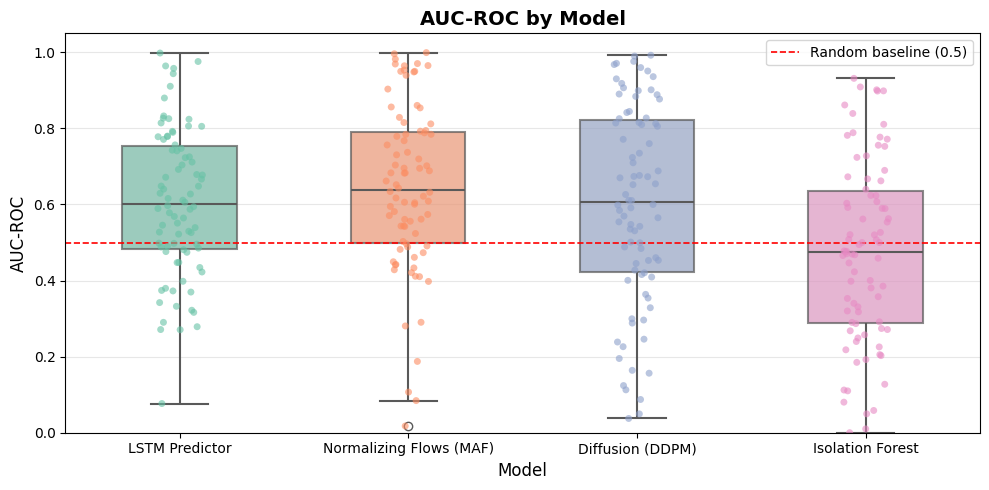

In [145]:
if len(results_df) == 0:
    print("No results available for plotting.")
else:
    plot_df = results_df.copy()
    plot_df["Model"] = plot_df["model"].map(MODEL_NAMES)

    fig, ax = plt.subplots(figsize=(10, 5))

    palette = sns.color_palette("Set2", n_colors=len(MODELS))
    model_order = [MODEL_NAMES[m] for m in MODELS]

    sns.boxplot(
        data=plot_df, x="Model", y="auc_roc",
        order=model_order, palette=palette,
        width=0.5, linewidth=1.5, ax=ax,
        boxprops=dict(alpha=0.7),
    )
    sns.stripplot(
        data=plot_df, x="Model", y="auc_roc",
        order=model_order, palette=palette,
        size=5, jitter=True, alpha=0.6, ax=ax,
    )
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.2, label="Random baseline (0.5)")
    ax.set_title("AUC-ROC by Model", fontsize=14, fontweight="bold")
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("AUC-ROC", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## F1 Score: Raw vs Point-Adjusted

Point-Adjust (PA) inflates F1 because detecting even a single anomalous timestep credits the model with the entire anomaly segment. The gap between Raw and PA F1 illustrates how much each model benefits from this lenient protocol.

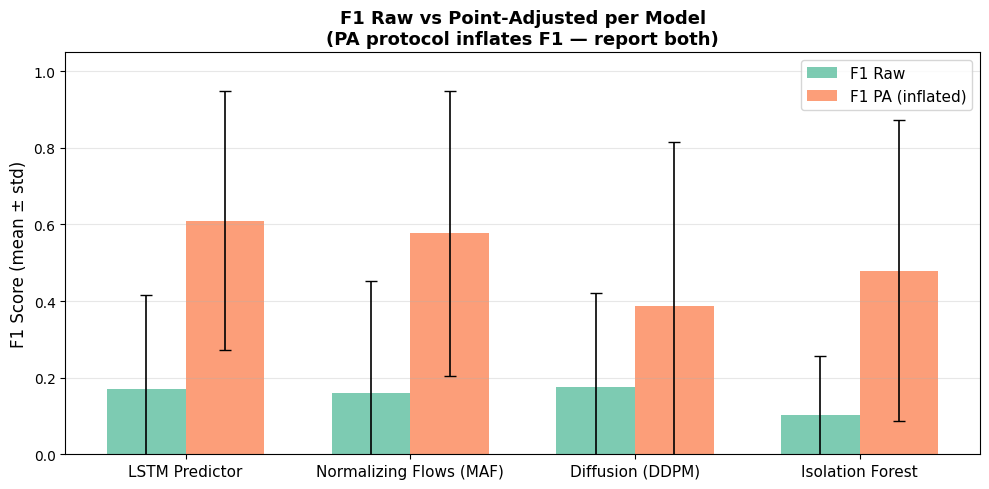

In [146]:
if len(results_df) == 0:
    print("No results available for plotting.")
else:
    # Build a tidy dataframe for grouped barplot
    mean_df = results_df.groupby("model")[["f1_raw", "f1_pa"]].mean().reset_index()
    std_df  = results_df.groupby("model")[["f1_raw", "f1_pa"]].std().reset_index()

    model_order = MODELS
    x = np.arange(len(model_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    palette = sns.color_palette("Set2", 2)

    bars_raw = ax.bar(
        x - width / 2,
        [mean_df.loc[mean_df["model"] == m, "f1_raw"].values[0] if m in mean_df["model"].values else 0 for m in model_order],
        width, yerr=
        [std_df.loc[std_df["model"] == m, "f1_raw"].values[0] if m in std_df["model"].values else 0 for m in model_order],
        label="F1 Raw", color=palette[0], alpha=0.85, capsize=4, error_kw=dict(elinewidth=1.2)
    )
    bars_pa = ax.bar(
        x + width / 2,
        [mean_df.loc[mean_df["model"] == m, "f1_pa"].values[0] if m in mean_df["model"].values else 0 for m in model_order],
        width, yerr=
        [std_df.loc[std_df["model"] == m, "f1_pa"].values[0] if m in std_df["model"].values else 0 for m in model_order],
        label="F1 PA (inflated)", color=palette[1], alpha=0.85, capsize=4, error_kw=dict(elinewidth=1.2)
    )

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_NAMES[m] for m in model_order], fontsize=11)
    ax.set_ylabel("F1 Score (mean ± std)", fontsize=12)
    ax.set_title("F1 Raw vs Point-Adjusted per Model\n(PA protocol inflates F1 — report both)", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## Score Distribution Comparison (Sample Entity)

Visual inspection of raw anomaly scores vs. ground-truth anomaly segments for a single representative entity.

Sample entity: P-1 (SMAP)


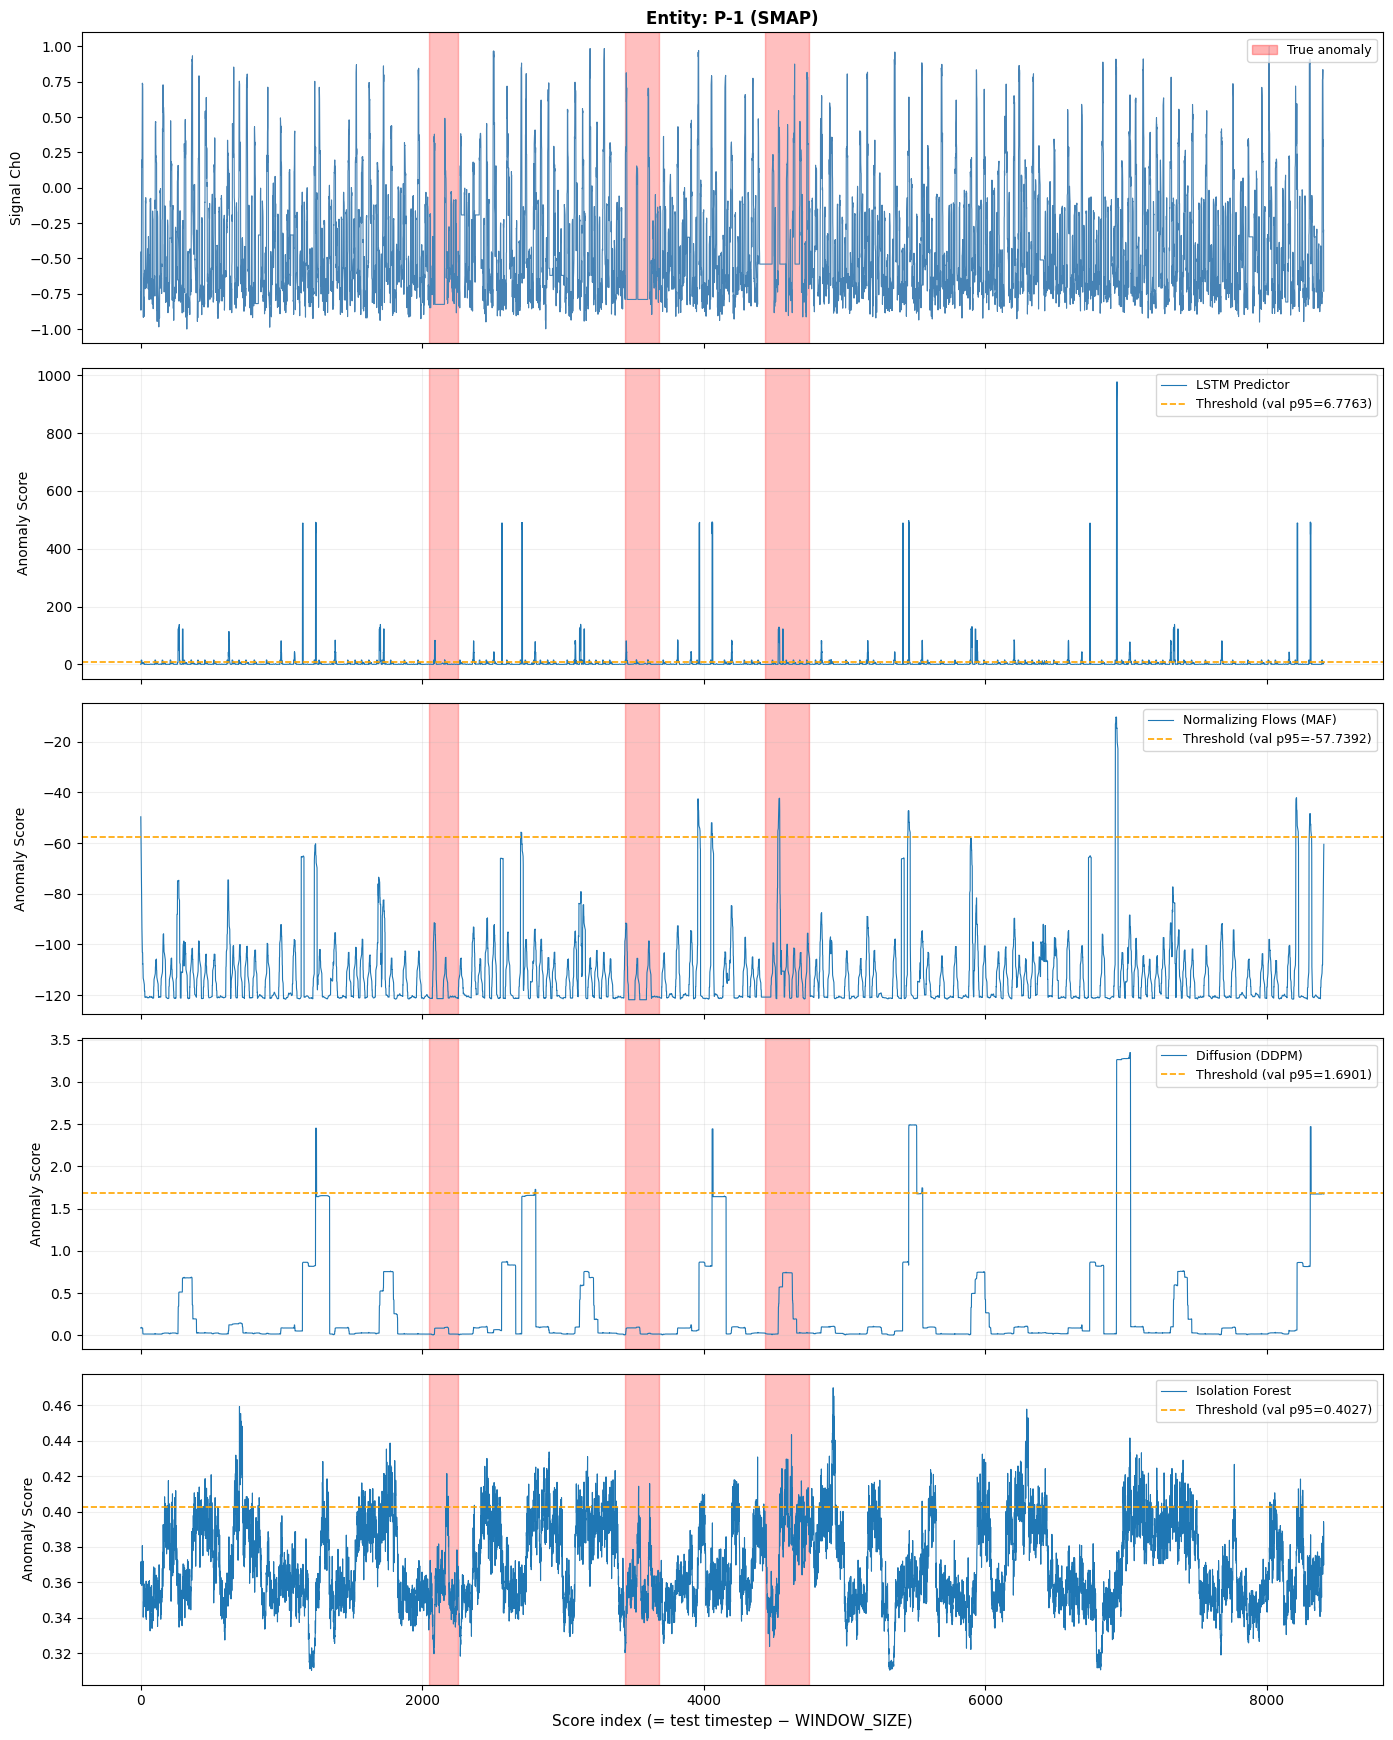

In [147]:
# Pick first entity that has anomalies and scores for all 3 models
sample_entity = None
sample_row = None

for _, row in labels_df.iterrows():
    eid = row["chan_id"]
    if eid not in fully_evaluated:
        continue
    seqs = row["anomaly_sequences"]
    if len(seqs) == 0:
        continue
    # Check all score files exist
    all_exist = all(
        (RESULTS_DIR / m / f"{eid}_test_scores.npy").exists() and
        (RESULTS_DIR / m / f"{eid}_val_scores.npy").exists()
        for m in MODELS
    )
    if all_exist:
        sample_entity = eid
        sample_row = row
        break

if sample_entity is None:
    print("No suitable sample entity found — run model notebooks first.")
else:
    print(f"Sample entity: {sample_entity} ({sample_row['spacecraft']})")

    # Load scores for all models
    model_scores = {}
    model_thresholds = {}
    for m in MODELS:
        ts = np.load(RESULTS_DIR / m / f"{sample_entity}_test_scores.npy")
        vs = np.load(RESULTS_DIR / m / f"{sample_entity}_val_scores.npy")
        model_scores[m] = ts
        model_thresholds[m] = np.percentile(vs, 95)

    test_len = len(model_scores[MODELS[0]]) + WINDOW_SIZE
    gt_labels = build_ground_truth(sample_row["anomaly_sequences"], test_len, WINDOW_SIZE)

    # Try to load raw test data channel 0 for signal panel
    signal = None
    for data_dir in [Path("data"), Path("data/test"), Path("SMAP_MSL/test")]:
        candidate = data_dir / f"{sample_entity}.npy"
        if candidate.exists():
            try:
                raw = np.load(candidate)
                signal = raw[:, 0] if raw.ndim == 2 else raw
            except Exception:
                pass
            break

    n_panels = 1 + len(MODELS)
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3.5 * n_panels), sharex=True)

    score_x = np.arange(len(gt_labels))  # score index == timestep - WINDOW_SIZE

    # Helper to shade anomaly segments
    def shade_anomalies(ax, labels):
        in_seg = False
        for i, lbl in enumerate(labels):
            if lbl == 1 and not in_seg:
                seg_s = i
                in_seg = True
            elif lbl == 0 and in_seg:
                ax.axvspan(seg_s, i, alpha=0.25, color="red", label="_nolegend_")
                in_seg = False
        if in_seg:
            ax.axvspan(seg_s, len(labels), alpha=0.25, color="red")

    # Panel 1 — raw signal or placeholder
    ax0 = axes[0]
    if signal is not None:
        sig_plot = signal[WINDOW_SIZE:WINDOW_SIZE + len(score_x)]
        ax0.plot(score_x[:len(sig_plot)], sig_plot, color="steelblue", linewidth=0.8)
        ax0.set_ylabel("Signal Ch0", fontsize=10)
    else:
        ax0.text(0.5, 0.5, "Raw signal not found\n(run data prep notebook to save test arrays)",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=10, color="grey")
        ax0.set_ylabel("Signal Ch0", fontsize=10)
    shade_anomalies(ax0, gt_labels)
    anomaly_patch = mpatches.Patch(color="red", alpha=0.3, label="True anomaly")
    ax0.legend(handles=[anomaly_patch], fontsize=9, loc="upper right")
    ax0.set_title(f"Entity: {sample_entity} ({sample_row['spacecraft']})", fontsize=12, fontweight="bold")

    # Panels 2-4 — model scores
    for idx, m in enumerate(MODELS):
        ax = axes[idx + 1]
        sc = model_scores[m]
        thr = model_thresholds[m]
        ax.plot(score_x[:len(sc)], sc, linewidth=0.8, label=MODEL_NAMES[m])
        ax.axhline(thr, color="orange", linestyle="--", linewidth=1.2, label=f"Threshold (val p95={thr:.4f})")
        shade_anomalies(ax, gt_labels[:len(sc)])
        ax.set_ylabel("Anomaly Score", fontsize=10)
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Score index (= test timestep − WINDOW_SIZE)", fontsize=11)
    plt.tight_layout()
    plt.show()

## SMAP vs MSL Breakdown

SMAP and MSL have different characteristics (number of channels, anomaly density). This section compares model AUC-ROC separately for each spacecraft.

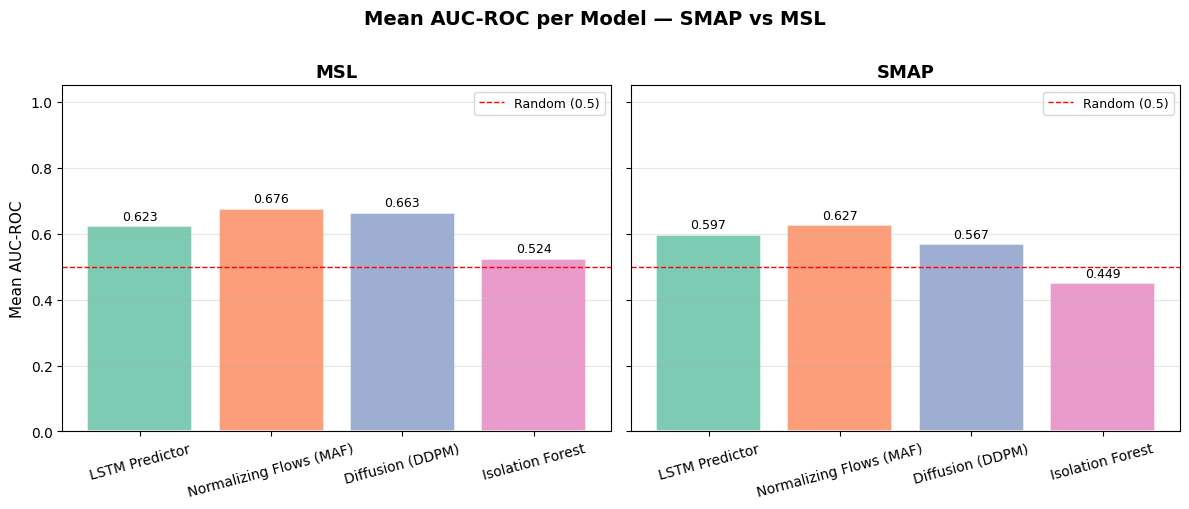

In [148]:
if len(results_df) == 0:
    print("No results available for plotting.")
else:
    sc_agg = (
        results_df.groupby(["model", "spacecraft"])["auc_roc"]
        .mean()
        .reset_index()
    )
    sc_agg["Model"] = sc_agg["model"].map(MODEL_NAMES)

    spacecrafts = sorted(sc_agg["spacecraft"].unique())
    fig, axes = plt.subplots(1, len(spacecrafts), figsize=(12, 5), sharey=True)

    if len(spacecrafts) == 1:
        axes = [axes]

    palette = sns.color_palette("Set2", n_colors=len(MODELS))
    model_order_names = [MODEL_NAMES[m] for m in MODELS]

    for ax, sc in zip(axes, spacecrafts):
        subset = sc_agg[sc_agg["spacecraft"] == sc]
        # Reorder
        subset = subset.set_index("Model").reindex(model_order_names).reset_index()
        bars = ax.bar(
            subset["Model"], subset["auc_roc"],
            color=palette[:len(subset)], alpha=0.85, edgecolor="white", linewidth=1.2
        )
        ax.axhline(0.5, color="red", linestyle="--", linewidth=1.0, label="Random (0.5)")
        ax.set_title(sc, fontsize=13, fontweight="bold")
        ax.set_ylabel("Mean AUC-ROC" if ax == axes[0] else "", fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=15)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=9)
        for bar, val in zip(bars, subset["auc_roc"]):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2, val + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9
                )

    fig.suptitle("Mean AUC-ROC per Model — SMAP vs MSL", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## Conclusions

In [149]:
if len(results_df) == 0:
    print("No results available — run model notebooks (03, 04, 05) first, then re-run this notebook.")
else:
    agg_mean = results_df.groupby("model")[["auc_roc", "f1_raw", "f1_pa"]].mean()

    best_auc  = agg_mean["auc_roc"].idxmax()
    best_f1r  = agg_mean["f1_raw"].idxmax()
    best_f1pa = agg_mean["f1_pa"].idxmax()

    # SMAP vs MSL AUC gap per model
    sc_pivot = results_df.groupby(["model", "spacecraft"])["auc_roc"].mean().unstack()

    # PA vs raw gap
    pa_gap = (agg_mean["f1_pa"] - agg_mean["f1_raw"]).round(3)

    summary = [
        "=" * 65,
        "  FINAL EVALUATION SUMMARY — NASA SMAP/MSL Anomaly Detection",
        "=" * 65,
        "",
        f"  Entities evaluated:  {results_df['entity'].nunique()}",
        f"  Models compared:     {', '.join(MODEL_NAMES[m] for m in MODELS)}",
        "",
        "  ── Best Model by Metric ─────────────────────────────────────",
        f"  AUC-ROC  : {MODEL_NAMES[best_auc]:30s}  ({agg_mean.loc[best_auc, 'auc_roc']:.3f})",
        f"  F1 Raw   : {MODEL_NAMES[best_f1r]:30s}  ({agg_mean.loc[best_f1r, 'f1_raw']:.3f})",
        f"  F1 PA    : {MODEL_NAMES[best_f1pa]:30s}  ({agg_mean.loc[best_f1pa, 'f1_pa']:.3f})",
        "",
        "  ── Point-Adjust vs Raw F1 Gap ───────────────────────────────",
    ]
    for m in MODELS:
        summary.append(f"  {MODEL_NAMES[m]:30s}  +{pa_gap[m]:.3f}")
    summary += [
        "",
        "  Note: PA protocol grants full-segment credit for any detected",
        "  point within an anomaly window.  Raw F1 is the stricter and",
        "  more informative metric for real deployment scenarios.",
        "",
    ]

    if "SMAP" in sc_pivot.columns and "MSL" in sc_pivot.columns:
        summary.append("  ── SMAP vs MSL AUC-ROC ──────────────────────────────────────")
        for m in MODELS:
            if m in sc_pivot.index:
                smap_v = sc_pivot.loc[m, "SMAP"] if "SMAP" in sc_pivot.columns else float("nan")
                msl_v  = sc_pivot.loc[m, "MSL"]  if "MSL"  in sc_pivot.columns else float("nan")
                diff   = smap_v - msl_v if not (np.isnan(smap_v) or np.isnan(msl_v)) else float("nan")
                summary.append(
                    f"  {MODEL_NAMES[m]:30s}  SMAP={smap_v:.3f}  MSL={msl_v:.3f}  "
                    f"({'SMAP higher' if diff > 0 else 'MSL higher' if diff < 0 else 'equal'})"
                )
        summary += [
            "",
            "  SMAP has more channels and shorter anomaly bursts; MSL anomalies",
            "  tend to be longer and more pronounced.  Models may differ in",
            "  sensitivity depending on the anomaly duration and channel count.",
        ]

    summary.append("=" * 65)
    print("\n".join(summary))

  FINAL EVALUATION SUMMARY — NASA SMAP/MSL Anomaly Detection

  Entities evaluated:  81
  Models compared:     LSTM Predictor, Normalizing Flows (MAF), Diffusion (DDPM), Isolation Forest

  ── Best Model by Metric ─────────────────────────────────────
  AUC-ROC  : Normalizing Flows (MAF)         (0.643)
  F1 Raw   : Diffusion (DDPM)                (0.176)
  F1 PA    : LSTM Predictor                  (0.610)

  ── Point-Adjust vs Raw F1 Gap ───────────────────────────────
  LSTM Predictor                  +0.438
  Normalizing Flows (MAF)         +0.417
  Diffusion (DDPM)                +0.211
  Isolation Forest                +0.377

  Note: PA protocol grants full-segment credit for any detected
  point within an anomaly window.  Raw F1 is the stricter and
  more informative metric for real deployment scenarios.

  ── SMAP vs MSL AUC-ROC ──────────────────────────────────────
  LSTM Predictor                  SMAP=0.597  MSL=0.623  (MSL higher)
  Normalizing Flows (MAF)         SMAP=0.